In [34]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import ConfusionMatrixDisplay 

In [35]:
matches = pd.read_csv('../data/processed/features_v4.csv')

In [36]:
features = [
    "EloDiff",
    "PPGDiff",
    "GoalAgainstDiffLast5",
    "ShotOTDiffLast5"
]

In [37]:
train = matches[matches['Season'] != '25-26'] 
test = matches[matches['Season'] == '25-26']

In [38]:
X_train = train[features] 
y_train = train['FTR'] 
X_test = test[features] 
y_test = test['FTR']

In [39]:
 
model = LogisticRegression(
    max_iter=1000
)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [40]:
preds = model.predict(X_test)

In [41]:
accuracy = accuracy_score(y_test, preds) 
print(accuracy)

0.48947368421052634


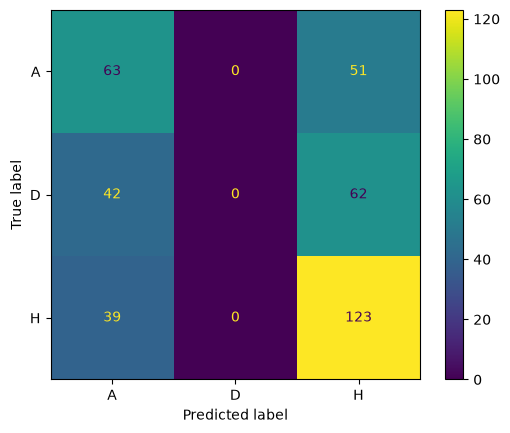

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, preds)

In [43]:
probs = model.predict_proba(X_test) 
print(model.classes_) 
print(probs[0])

['A' 'D' 'H']
[0.12867008 0.21545068 0.65587923]


In [44]:
importance = pd.DataFrame(
    model.coef_,
    columns=features,
    index=model.classes_
)

print(importance)

    EloDiff   PPGDiff  GoalAgainstDiffLast5  ShotOTDiffLast5
A -0.003396 -0.132542             -0.048658        -0.034565
D  0.000337  0.061720             -0.059929        -0.042734
H  0.003059  0.070821              0.108587         0.077299


In [45]:
print(log_loss(y_test, probs))

1.034520643807472


In [46]:
results = test[
    ["Season", "HomeTeam", "AwayTeam", "FTR"]
].copy()

results["Predicted"] = preds
results["AwayProb"] = probs[:, 0]
results["DrawProb"] = probs[:, 1]
results["HomeProb"] = probs[:, 2]

results.head(20)

,Season,HomeTeam,AwayTeam,FTR,Predicted,AwayProb,DrawProb,HomeProb
1520,25-26,Liverpool,Bournemouth,H,H,0.128670,0.215451,0.655879
1521,25-26,Aston Villa,Newcastle,D,H,0.314095,0.284669,0.401235
1522,25-26,Brighton,Fulham,D,H,0.209523,0.207996,0.582481
1523,25-26,Sunderland,West Ham,H,H,0.307828,0.284107,0.408065
1524,25-26,Tottenham,Burnley,H,H,0.271191,0.322155,0.406655
1525,25-26,Wolves,Man City,A,A,0.625510,0.221339,0.153152
1526,25-26,Chelsea,Crystal Palace,D,H,0.249942,0.265643,0.484415
1527,25-26,Nott'm Forest,Brentford,H,H,0.315988,0.271849,0.412163
1528,25-26,Man United,Arsenal,A,A,0.565101,0.223846,0.211053
1529,25-26,Leeds,Everton,H,A,0.528540,0.275273,0.196187
